In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shishiradh/stackoverflow-question-data-2020-2022/01_questions_base.parquet


In [2]:
df = pd.read_parquet("/kaggle/input/datasets/shishiradh/stackoverflow-question-data-2020-2022/01_questions_base.parquet")

In [3]:
df.head()

,question_id,creation_date,title,body,tags,owner_user_id,question_score,view_count,answer_count,comment_count,accepted_answer_id,accepted_answer_date,accepted_answer_score,minutes_to_accepted_answer,first_answer_date,minutes_to_first_answer,asker_reputation,asker_account_creation_date,asker_upvote_count,asker_downvote_count
0,65513537,2020-12-30 21:01:24.730000+00:00,automate creating subsets of data,<p>I am looking to subset a large amount of da...,r,13364594,2,71,3,1,65517284,2020-12-31 06:08:56.597000+00:00,2,547,2020-12-30 21:11:48.440000+00:00,10,77,2020-04-20 17:28:02.940000+00:00,22,0
1,68728972,2021-08-10 14:49:33.103000+00:00,Using MSAL with authentication context in C# W...,<p>We would like to use the authentication con...,c#|azure|azure-active-directory|msal,4210365,1,683,1,1,68737182,2021-08-11 06:43:47.867000+00:00,1,954,2021-08-11 06:43:47.867000+00:00,954,57,2014-11-03 12:27:30.420000+00:00,0,0
2,69346442,2021-09-27 12:16:08.950000+00:00,"Laravel Spatie Browsershot errno: -4058, code:...",<p>I am trying to capture a screenshot of my w...,laravel|browsershot,17015807,3,614,0,2,<NA>,NaT,<NA>,<NA>,NaT,<NA>,31,2021-09-27 11:53:44.423000+00:00,0,0
3,71696845,2022-03-31 17:28:04.337000+00:00,Twitch API Embed in Discord.Net C# Loop/Timer ...,<p>i have a currently working embed post when ...,c#|discord|discord.net,16464645,0,121,0,5,<NA>,NaT,<NA>,<NA>,NaT,<NA>,3,2021-07-16 17:31:07.730000+00:00,0,0
4,72564691,2022-06-09 18:00:06.833000+00:00,"Using PowerShell, how can I use Substring to e...",<p>I am new to PowerShell but I found I can us...,powershell|variables|substring,4015242,0,38,1,3,72567144,2022-06-09 22:07:28.383000+00:00,1,247,2022-06-09 22:07:28.383000+00:00,247,65,2014-09-06 19:32:12.953000+00:00,3,0


In [4]:
df.dtypes

question_id                                  Int64
creation_date                  datetime64[us, UTC]
title                                       object
body                                        object
tags                                        object
owner_user_id                                Int64
question_score                               Int64
view_count                                   Int64
answer_count                                 Int64
comment_count                                Int64
accepted_answer_id                           Int64
accepted_answer_date           datetime64[us, UTC]
accepted_answer_score                        Int64
minutes_to_accepted_answer                   Int64
first_answer_date              datetime64[us, UTC]
minutes_to_first_answer                      Int64
asker_reputation                             Int64
asker_account_creation_date    datetime64[us, UTC]
asker_upvote_count                           Int64
asker_downvote_count           

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

question_id                          0
creation_date                        0
title                                0
body                                 0
tags                                 0
owner_user_id                    45932
question_score                       0
view_count                           0
answer_count                         0
comment_count                        0
accepted_answer_id             2096203
accepted_answer_date           2096203
accepted_answer_score          2096203
minutes_to_accepted_answer     2096203
first_answer_date               966919
minutes_to_first_answer         966919
asker_reputation                 45935
asker_account_creation_date      45935
asker_upvote_count               45935
asker_downvote_count             45935
dtype: int64

In [7]:
print(df.shape)

(3340708, 20)


In [8]:
int_cols = ['question_score', 'view_count', 'answer_count', 'comment_count',
            'accepted_answer_score', 'minutes_to_accepted_answer', 'minutes_to_first_answer',
            'asker_reputation', 'asker_upvote_count', 'asker_downvote_count']

for col in int_cols:
    df[col] = df[col].astype('float64')

In [9]:
df.dtypes

question_id                                  Int64
creation_date                  datetime64[us, UTC]
title                                       object
body                                        object
tags                                        object
owner_user_id                                Int64
question_score                             float64
view_count                                 float64
answer_count                               float64
comment_count                              float64
accepted_answer_id                           Int64
accepted_answer_date           datetime64[us, UTC]
accepted_answer_score                      float64
minutes_to_accepted_answer                 float64
first_answer_date              datetime64[us, UTC]
minutes_to_first_answer                    float64
asker_reputation                           float64
asker_account_creation_date    datetime64[us, UTC]
asker_upvote_count                         float64
asker_downvote_count           

In [10]:
# Setup

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df['is_answered'] = df['first_answer_date'].notna()
df['is_accepted'] = df['accepted_answer_id'].notna()

print(df.shape)
df.dtypes

(3340708, 22)


question_id                                  Int64
creation_date                  datetime64[us, UTC]
title                                       object
body                                        object
tags                                        object
owner_user_id                                Int64
question_score                             float64
view_count                                 float64
answer_count                               float64
comment_count                              float64
accepted_answer_id                           Int64
accepted_answer_date           datetime64[us, UTC]
accepted_answer_score                      float64
minutes_to_accepted_answer                 float64
first_answer_date              datetime64[us, UTC]
minutes_to_first_answer                    float64
asker_reputation                           float64
asker_account_creation_date    datetime64[us, UTC]
asker_upvote_count                         float64
asker_downvote_count           

## 1. Target variable analysis

In [11]:
print("Answered vs Unanswered")
print(df['is_answered'].value_counts(normalize=True))
print("\n")

print("Accepted vs Unaccepted")
print(df['is_accepted'].value_counts(normalize=True))

pd.crosstab(df['is_answered'],df['is_accepted'], normalize='index')

Answered vs Unanswered
is_answered
True     0.710565
False    0.289435
Name: proportion, dtype: float64


Accepted vs Unaccepted
is_accepted
False    0.627473
True     0.372527
Name: proportion, dtype: float64


is_accepted,False,True
is_answered,,
False,1.000000,0.000000
True,0.475731,0.524269


* 71.06% of questions get some answer but only 37.25% get a formally accepted one.
* Of answered questions, only 52.4% get accepted. Meanwhile the other 47.7% get real help that's never marked accepted.
* This is the clearest evidence that "accepted" undercounts actual help, and justifies using is_answered/first-answer-time as our primary target over acceptance-based labels.

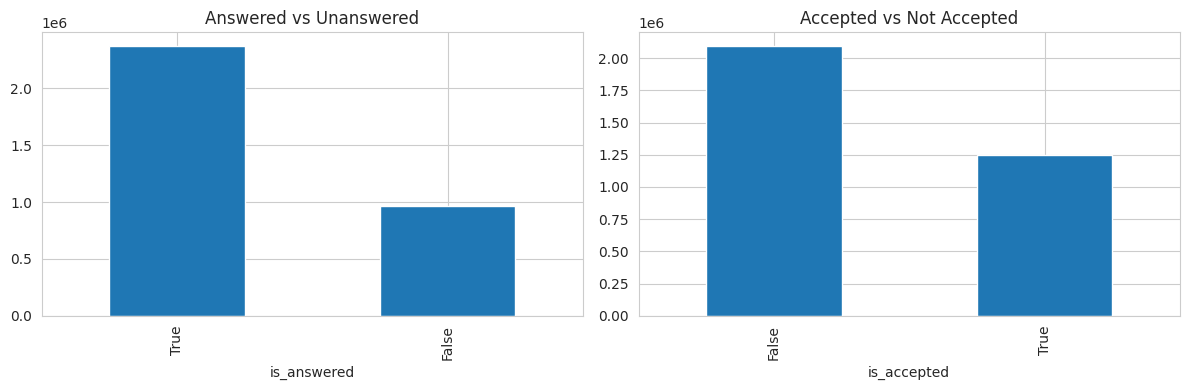

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['is_answered'].value_counts().plot(kind='bar', ax=axes[0], title='Answered vs Unanswered')
df['is_accepted'].value_counts().plot(kind='bar', ax=axes[1], title='Accepted vs Not Accepted')
plt.tight_layout()
plt.show()

## 2. Time-to-answer distribution

count    2.373789e+06
mean     1.694306e+02
std      9.398818e+02
min     -4.674315e+04
25%      2.333333e-01
50%      1.000000e+00
75%      9.833333e+00
max      1.735393e+04
Name: hours_to_first_answer, dtype: float64


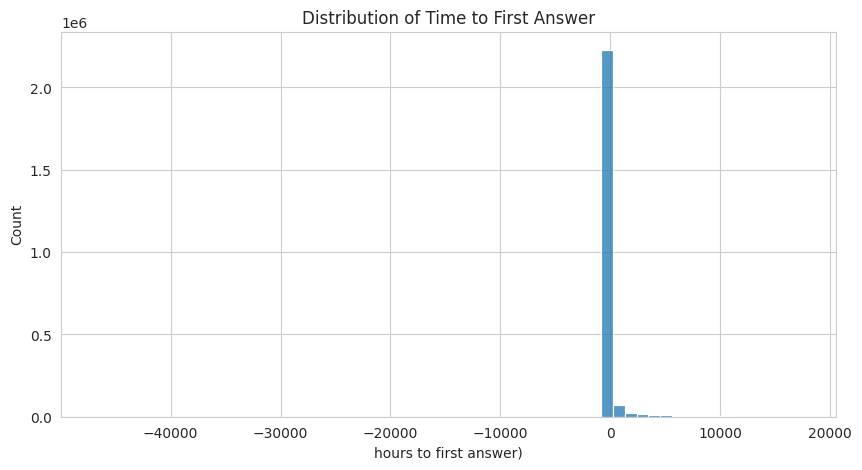

In [13]:
# Convert minutes to hours
df['hours_to_first_answer'] = df['minutes_to_first_answer']/60
df['hours_to_accepted_answer'] = df['minutes_to_accepted_answer']/60

print(df['hours_to_first_answer'].describe())

plt.figure(figsize=(10,5))
sns.histplot(
    df.loc[df['is_answered'], 'hours_to_first_answer'],
    bins=60
)
plt.xlabel('hours to first answer)')
plt.title('Distribution of Time to First Answer')
plt.show()

A anomaly is found as minimum "hours_to_first_answer" is negative(-46743.15).

In [14]:
negative_count = (df["hours_to_first_answer"] < 0).sum()

print(negative_count)

df.loc[
    df["hours_to_first_answer"] < 0
].head()

12


,question_id,creation_date,title,body,tags,owner_user_id,question_score,view_count,answer_count,comment_count,...,first_answer_date,minutes_to_first_answer,asker_reputation,asker_account_creation_date,asker_upvote_count,asker_downvote_count,is_answered,is_accepted,hours_to_first_answer,hours_to_accepted_answer
20947,70247507,2021-12-06 15:00:22.943000+00:00,Word ribbon appears to ignore insertAfterMso w...,<p>I have a ribbon that I need to position aft...,ms-word|vsto|ribbonx,1100206,1.0,157.0,2.0,2.0,...,2021-12-02 21:37:52.333000+00:00,-5362.0,1018.0,2011-12-15 15:34:45.420000+00:00,174.0,16.0,True,True,-89.366667,0.00
179329,64560461,2020-10-27 18:09:43.007000+00:00,The parameter can't have a value of 'null' bec...,<h2>Dart function</h2>\n<p>I have the followin...,flutter|dart|dart-null-safety,6509751,112.0,133898.0,8.0,1.0,...,2020-04-15 01:46:04.810000+00:00,-281783.0,98788.0,2016-06-24 15:44:55.007000+00:00,2520.0,262.0,True,True,-4696.383333,0.00
531467,68121313,2021-06-24 18:52:19.420000+00:00,How can I put words from a list into a table?,<p><strong>Note: I want to achieve this withou...,python|arrays|list,16256257,2.0,83.0,3.0,0.0,...,2021-06-21 21:05:44.153000+00:00,-4186.0,33.0,2021-06-17 21:32:07.897000+00:00,4.0,0.0,True,True,-69.766667,0.15
807537,72063568,2022-04-29 20:51:35.623000+00:00,What is this inefficient sorting algorithm wit...,<p>What type of sort is this? It seems to be n...,java|algorithm|sorting,16535849,-4.0,74.0,1.0,3.0,...,2022-04-11 08:26:41.480000+00:00,-26664.0,75.0,2021-07-27 08:40:58.507000+00:00,47.0,0.0,True,True,-444.400000,-444.40
828789,66075884,2021-02-06 10:33:39.237000+00:00,Capturing all the occurrences of a specific wo...,<p>I'm trying to get with a regex using PCRE2 ...,regex|pcre,10075394,3.0,274.0,5.0,4.0,...,2015-10-08 19:24:37.287000+00:00,-2804589.0,11335.0,2018-07-13 10:04:56.430000+00:00,1602.0,13.0,True,True,-46743.150000,0.20


In [15]:
# Removing the negative hours_to_first_answer rows

# df = df[df["hours_to_first_answer"] >= 0] --> using this also removed the NaN rows consequently all rows for is_answered = False are removed bcoz NAN >= 0 is False.

df = df[
    (df["hours_to_first_answer"] >= 0) |
    (df["is_answered"] == False)
].copy()

df["hours_to_first_answer"].describe()

count    2.373777e+06
mean     1.694557e+02
std      9.393815e+02
min      0.000000e+00
25%      2.333333e-01
50%      1.000000e+00
75%      9.833333e+00
max      1.735393e+04
Name: hours_to_first_answer, dtype: float64

In [16]:
# Check
df['is_answered'].value_counts(normalize=True)

is_answered
True     0.710564
False    0.289436
Name: proportion, dtype: float64

In [17]:
(df["hours_to_accepted_answer"] < 0).sum()

np.int64(0)

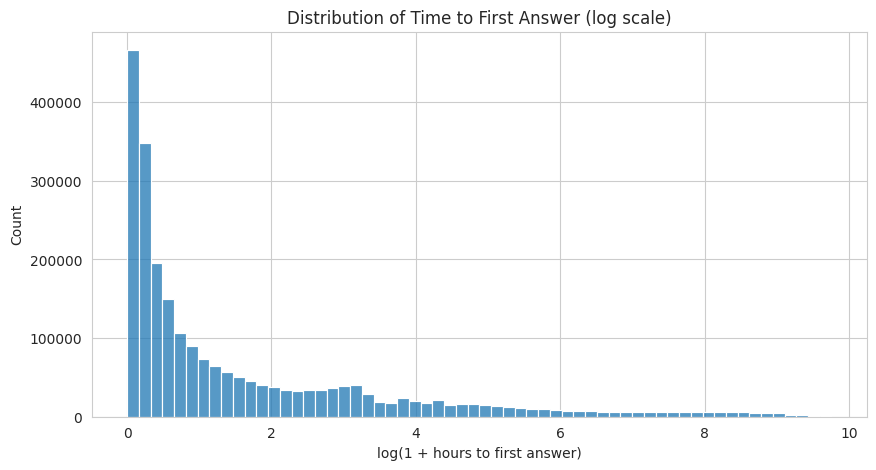

In [18]:
# As the distribution is highly skewed (mean 169 hours vs. median 1 hour) : most questions were answered fast
# So using log-transform to compress large values for visualization
# Perform log(1+x) -- not log(x) bcoz log(0) gives infinity

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df.loc[df['is_answered'], 'hours_to_first_answer']), bins=60)
plt.xlabel('log(1 + hours to first answer)')
plt.title('Distribution of Time to First Answer (log scale)')
plt.show()

In [19]:
answered = df[df['is_answered']]
for hours in [1,6,24,72,168]:
    pct = (answered['hours_to_first_answer'] <= hours).mean()*100
    print(f"Answered within {hours}h: {pct:.2f}%")

Answered within 1h: 50.15%
Answered within 6h: 71.00%
Answered within 24h: 82.90%
Answered within 72h: 89.03%
Answered within 168h: 92.50%


50.15% of eventually-answered questions get answered within 1 hour; 92.5% within a week.

## 3. When questions are posted and answered?

/tmp/ipykernel_58/4071836058.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['post_month'] = df['creation_date'].dt.to_period('M')


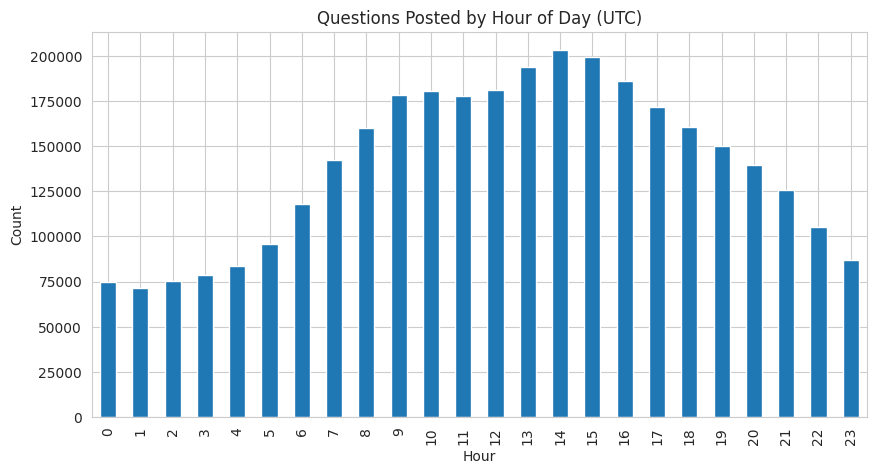

In [20]:
df['post_hour'] = df['creation_date'].dt.hour
df['post_dayofweek'] = df['creation_date'].dt.day_name()
df['post_month'] = df['creation_date'].dt.to_period('M')

# Volume by hour of day
plt.figure(figsize=(10,5))
df['post_hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Questions Posted by Hour of Day (UTC)')
plt.xlabel('Hour'); plt.ylabel('Count')
plt.show()

Posting volume peaks 9:00–16:00 UTC, troughs 0:00–2:00 UTC — consistent with US/Europe waking hours.

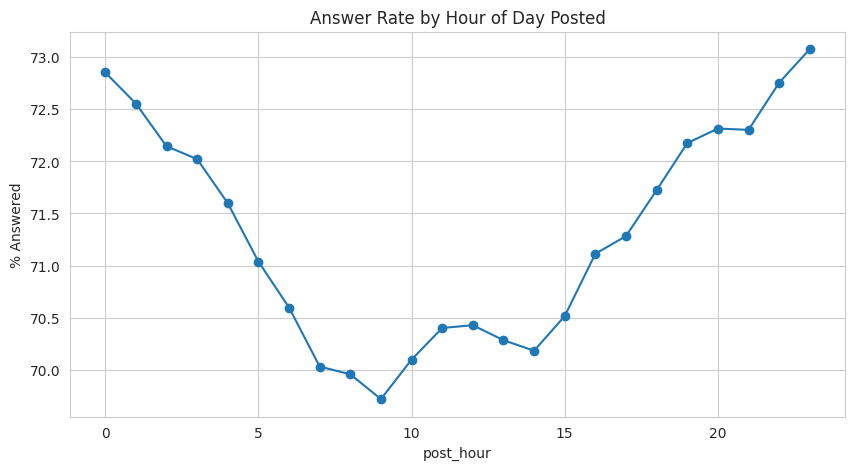

In [21]:
# Answer rate by hour of day — does posting time affect your odds of getting answered?

answer_rate_by_hour = df.groupby('post_hour')['is_answered'].mean().mul(100)

plt.figure(figsize=(10,5))
answer_rate_by_hour.plot(kind='line', marker='o')
plt.title('Answer Rate by Hour of Day Posted')
plt.ylabel('% Answered')
plt.show()

* Answer rate is lowest (≈69.7–70.7%) during the same 7:00–14:00 UTC window where posting volume is highest, and highest (≈72.5–73%) during low-volume overnight hours.
* This suggests a supply/demand effect i.e. more questions competing for answerer attention during peak hours.

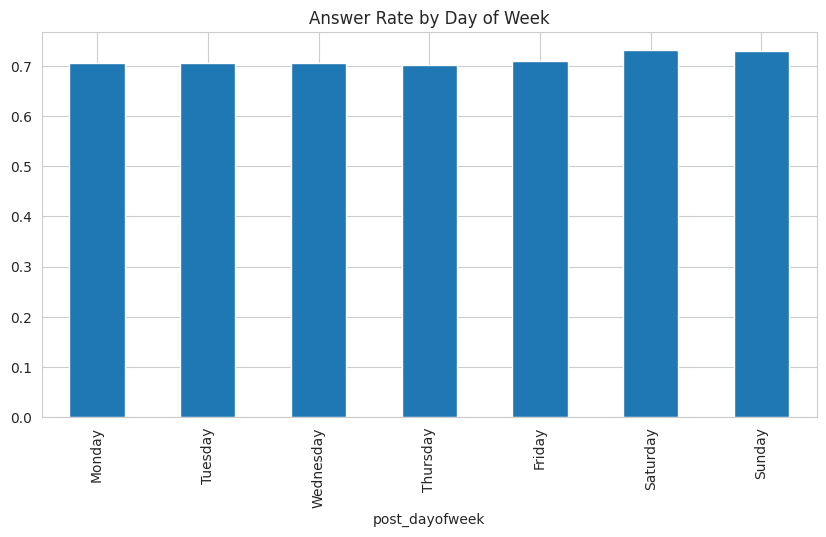

In [22]:
# Answer rate by day of week

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
answer_rate_by_day = df.groupby('post_dayofweek')['is_answered'].mean().reindex(order)
answer_rate_by_day.plot(kind='bar', title='Answer Rate by Day of Week')
plt.show()

Day-of-week answer rate is fairly flat (≈70–73%) with a mild bump on Saturday and Sunday.

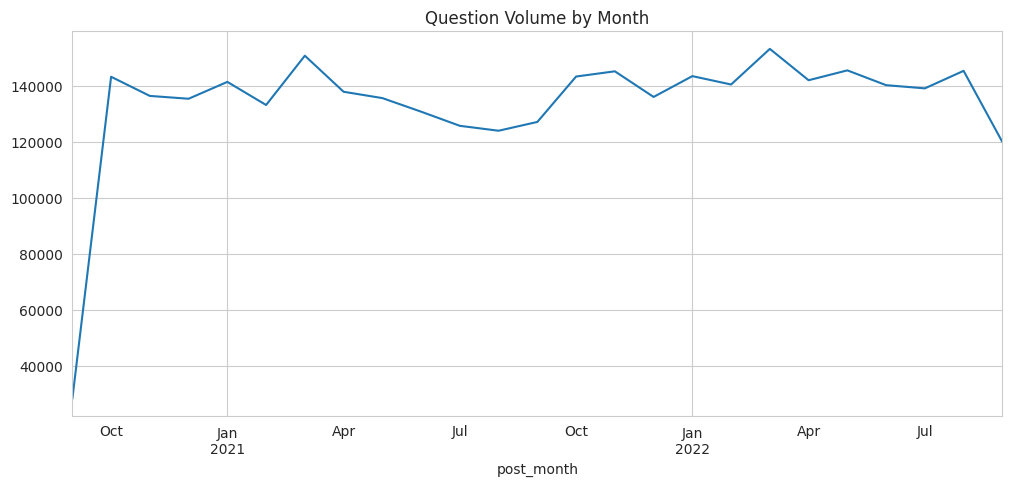

In [23]:
# Monthly volume trend over the full 2-year window: Is StackOverflow activity growing or shrinking?

monthly_volume = df.groupby('post_month').size()
monthly_volume.plot(kind='line', title='Question Volume by Month', figsize=(12,5))
plt.show()

**Note:** Monthly volume looks like it dips sharply at both ends of the chart: this is very likely a data-boundary artifact, not a real trend. Our window starts and ends mid-month (Sept 25, 2020 and Sept 25, 2022), so the first and last bars are partial months, not genuine low-activity periods.

## 4. Tag Analysis

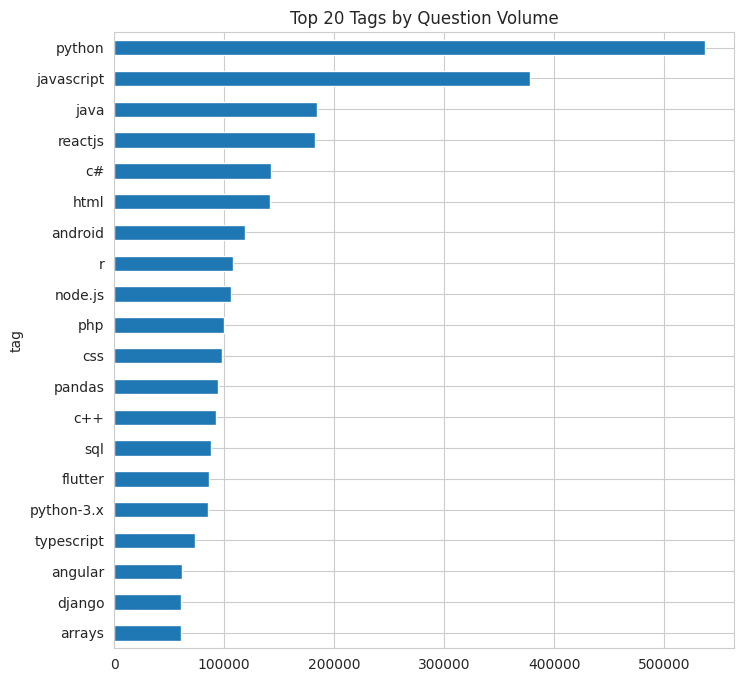

In [24]:
# As we saw earlier tags are stored as a pipe-separated string (|)

df['tag_list'] = df['tags'].str.split('|')
df['num_tags'] = df['tag_list'].apply(len)

# Explode to one row per (question, tag) pair for tag-level analysis
tags_exploded = df.explode('tag_list').rename(columns={'tag_list': 'tag'})
top_tags = tags_exploded['tag'].value_counts().head(20)
top_tags.plot(kind='barh', figsize=(8,8), title='Top 20 Tags by Question Volume')
plt.gca().invert_yaxis()
plt.show()

Python and JavaScript dominate volume, each far ahead of the next tier (Java, ReactJS, C#).

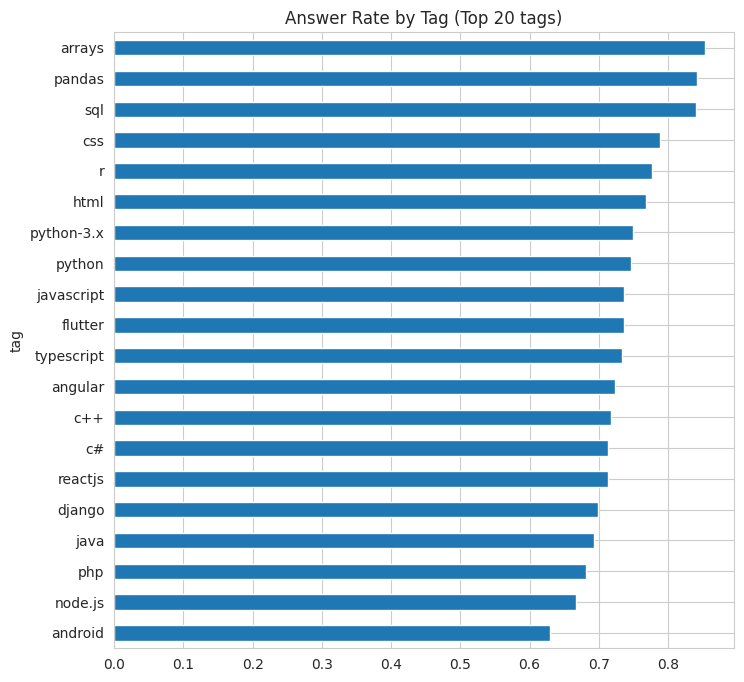

In [25]:
# Answer rate for the top 20 tags — which popular tags struggle to get answered?

top_tag_names = top_tags.index.tolist()
tag_answer_rate = (
    tags_exploded[tags_exploded['tag'].isin(top_tag_names)]
    .groupby('tag')['is_answered']
    .mean()
    .sort_values()
)
tag_answer_rate.plot(kind='barh', figsize=(8,8), title='Answer Rate by Tag (Top 20 tags)')
plt.show()

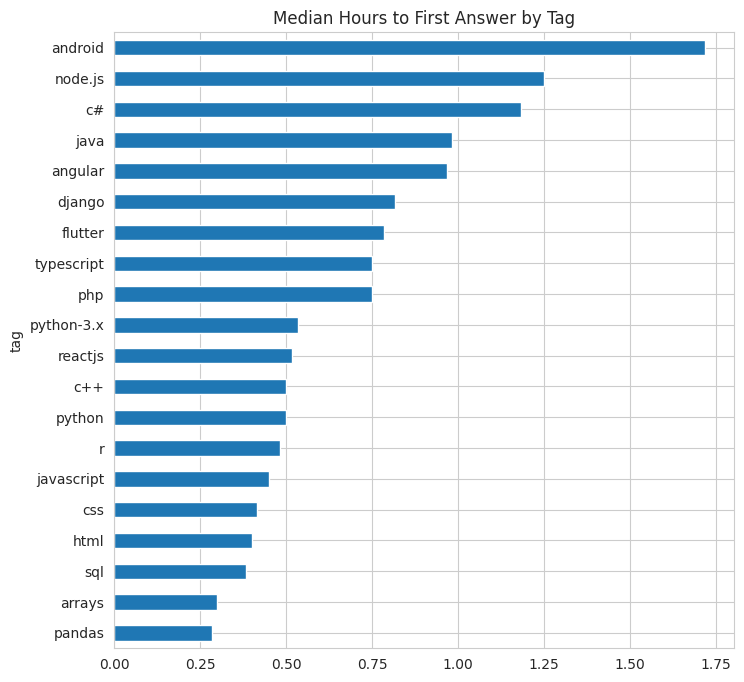

In [26]:
# Median time-to-answer by tag (only answered questions, top tags)
tag_speed = (
    tags_exploded[(tags_exploded['tag'].isin(top_tag_names)) & (tags_exploded['is_answered'])]
    .groupby('tag')['hours_to_first_answer']
    .median()
    .sort_values()
)
tag_speed.plot(kind='barh', figsize=(8,8), title='Median Hours to First Answer by Tag')
plt.show()

**Major, well-triangulated finding:** android has both the lowest answer rate (~63%) and the highest median time-to-answer (~1.7h) among top-20 tags.

* pandas, arrays, and sql are both fast and high-answer-rate. This likely reflects large, experienced answerer communities for those tags.

## 5. Text-based features: Title/Body characteristics

In [27]:
df['title_length'] = df['title'].str.len()
df['body_length'] = df['body'].str.len()
df['has_code_block'] = df['body'].str.contains('<code>', regex=False)  # StackOverflow stores body as HTML

print(df[['title_length', 'body_length']].describe())
print("\n% questions with a code block:", df['has_code_block'].mean()*100)

       title_length   body_length
count  3.340696e+06  3.340696e+06
mean   6.059649e+01  1.818435e+03
std    2.323607e+01  2.362322e+03
min    1.500000e+01  3.700000e+01
25%    4.400000e+01  6.560000e+02
50%    5.700000e+01  1.161000e+03
75%    7.300000e+01  2.078000e+03
max    1.500000e+02  1.159180e+05

% questions with a code block: 82.2595052049034


In [28]:
# Does having a code block correlate with getting answered?

print(df.groupby('has_code_block')['is_answered'].mean())

has_code_block
False    0.622909
True     0.729468
Name: is_answered, dtype: float64


Code-block presence correlates with a ~10.6 percentage-point higher answer rate (72.9% vs. 62.3%).

/tmp/ipykernel_58/3394857719.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('body_length_bucket')['is_answered'].mean().plot(kind='bar', title='Answer Rate by Body Length Quintile')


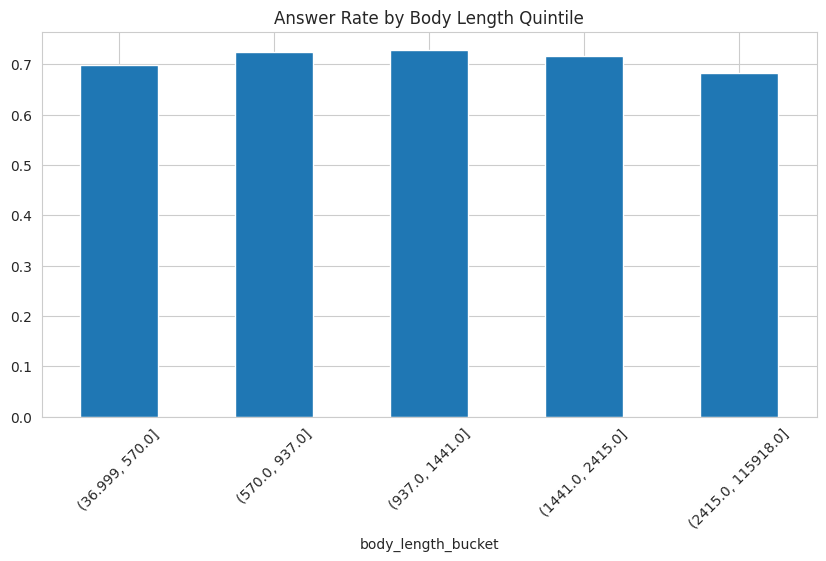

In [29]:
# Does body length correlate with answer likelihood?

df['body_length_bucket'] = pd.qcut(df['body_length'], q=5, duplicates='drop')
df.groupby('body_length_bucket')['is_answered'].mean().plot(kind='bar', title='Answer Rate by Body Length Quintile')
plt.xticks(rotation=45)
plt.show()

**Surprising, non-monotonic finding:** answer rate by body-length quintile is not a straight line. It rises from the shortest quintile, peaks in the middle quintiles, then drops for the longest quintile. Both very short and very long questions are answered less often than medium-length ones.

## 6. Asker reputation analysis

In [30]:
df['asker_reputation'].describe()

count    3.294761e+06
mean     1.299250e+03
std      8.640797e+03
min      1.000000e+00
25%      1.100000e+01
50%      5.900000e+01
75%      4.050000e+02
max      1.357603e+06
Name: asker_reputation, dtype: float64

Reputation is extremely right-skewed (mean 1,299, median 59, max 1.36M).

/tmp/ipykernel_58/1865465607.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('reputation_tier')['is_answered'].mean().plot(kind='bar', title='Answer Rate by Asker Reputation Tier')


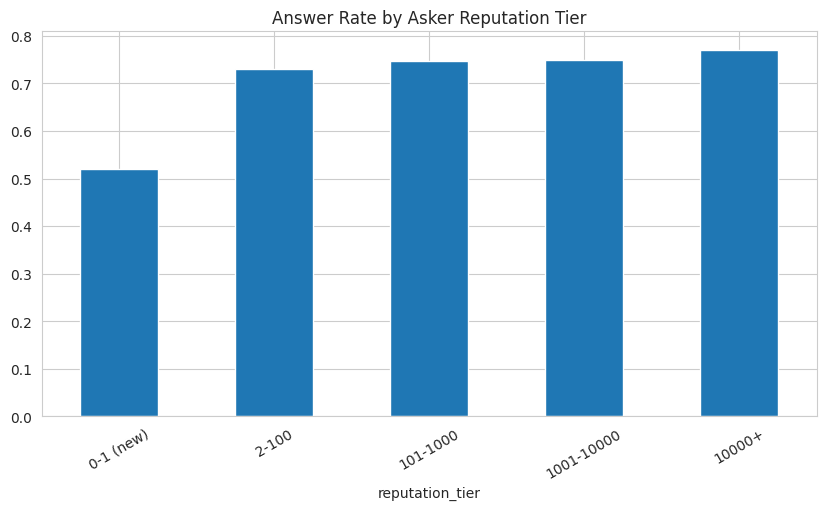

In [31]:
# Bucket reputation into tiers

df['reputation_tier'] = pd.cut(
    df['asker_reputation'],
    bins=[-1, 1, 100, 1000, 10000, np.inf],
    labels=['0-1 (new)', '2-100', '101-1000', '1001-10000', '10000+']
)

df.groupby('reputation_tier')['is_answered'].mean().plot(kind='bar', title='Answer Rate by Asker Reputation Tier')
plt.xticks(rotation=30)
plt.show()

**Major finding:** brand-new askers (0–1 reputation) have a markedly lower answer rate (~52%) than every other tier (73–77%), with a much smaller, more gradual increase across the remaining tiers. This looks like a distinct "newcomer penalty" rather than a smooth reputation effect

/tmp/ipykernel_58/2400203583.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['is_answered']].groupby('reputation_tier')['hours_to_first_answer'].median().plot(


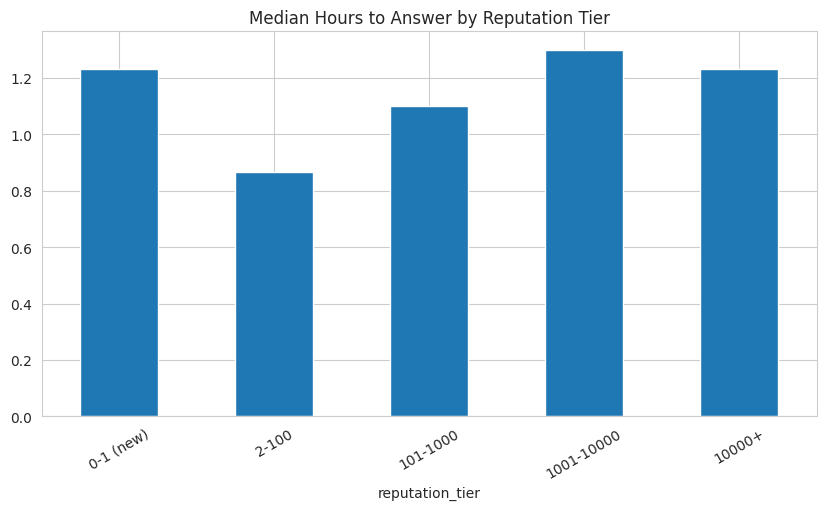

In [32]:
# Reputation vs speed of answer (median hours), only answered questions

df[df['is_answered']].groupby('reputation_tier')['hours_to_first_answer'].median().plot(
    kind='bar', title='Median Hours to Answer by Reputation Tier'
)
plt.xticks(rotation=30)
plt.show()

Among questions that do get answered, brand-new users are not the slowest — the 1,001–10,000 reputation tier has the highest median time-to-answer (~1.3h), slightly higher than new users (~1.23h), while the 2–100 tier is fastest (~0.87h). This is counterintuitive and likely reflects a selection effect: only "easier" questions from brand-new users get answered at all, so the ones that succeed resolve quickly, while more experienced users may ask harder questions that take longer even when answered.

## 7. Engagement metrics : score,views,comments

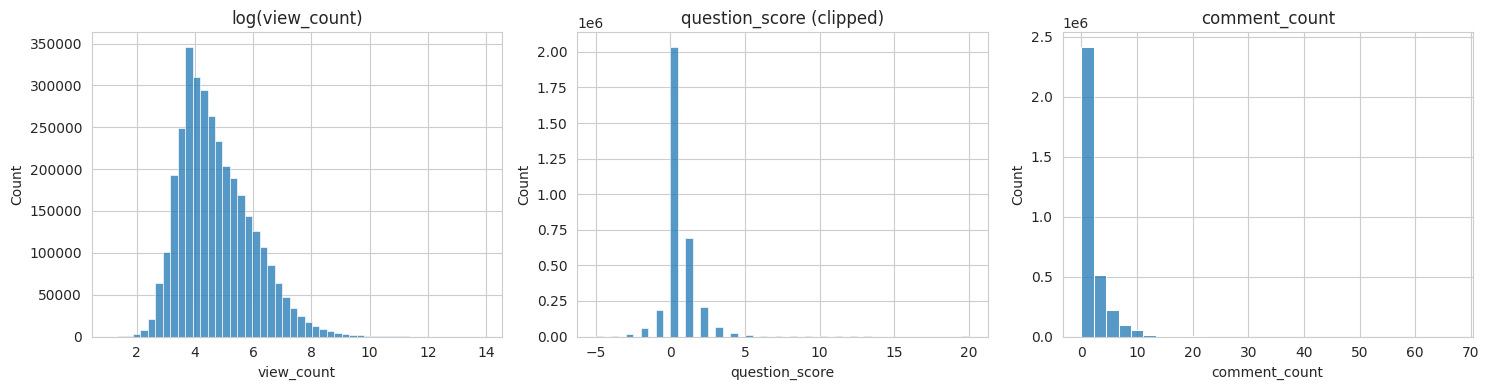

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(np.log1p(df['view_count']), bins=50, ax=axes[0]).set_title('log(view_count)')
sns.histplot(df['question_score'].clip(-5, 20), bins=50, ax=axes[1]).set_title('question_score (clipped)')
sns.histplot(df['comment_count'], bins=30, ax=axes[2]).set_title('comment_count')
plt.tight_layout()
plt.show()

## 8. Correlation check among numeric figures

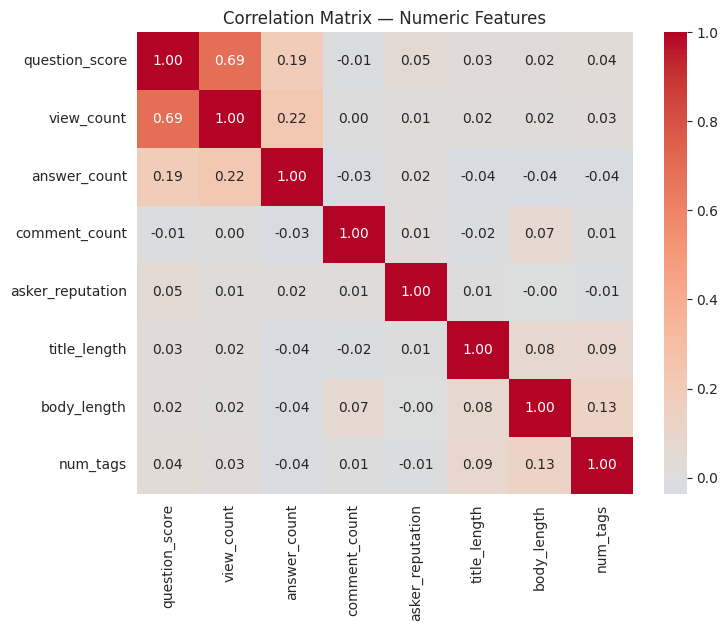

In [34]:
numeric_cols = ['question_score','view_count','answer_count','comment_count',
                 'asker_reputation','title_length','body_length','num_tags']

corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numeric Features')
plt.show()

* Only one meaningfully strong pairwise correlation: question_score and view_count at 0.69 — makes sense, more-viewed questions tend to accumulate more votes.
* Every other pair is weak (|r| < 0.2).

## 9. Multivariate Analysis: Is the "new user penalty" actually explained by new users writing shorter questions or lacking code blocks, or does reputation matter independently of those?

In [35]:
# Multivariate logistic regression

import statsmodels.formula.api as smf

# in statsmodels can be slow; a random subsample of ~300k is plenty for stable coefficients
reg_sample = df.sample(n=300_000, random_state=42).copy()

reg_sample['is_answered_int'] = reg_sample['is_answered'].astype(int)
reg_sample['has_code_block_int'] = reg_sample['has_code_block'].astype(int)

model_formula = (
    'is_answered_int ~ C(reputation_tier, Treatment(reference="0-1 (new)")) '
    '+ body_length + has_code_block_int + num_tags + title_length'
)

logit_model = smf.logit(formula=model_formula, data=reg_sample).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.585030
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        is_answered_int   No. Observations:               295899
Model:                          Logit   Df Residuals:                   295890
Method:                           MLE   Df Model:                            8
Date:                Thu, 27 Aug 2026   Pseudo R-squ.:                 0.02833
Time:                        14:55:52   Log-Likelihood:            -1.7311e+05
converged:                       True   LL-Null:                   -1.7816e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------

In [36]:
# Convert log-odds coefficients to odds ratios - much easier to interpret
odds_ratios = np.exp(logit_model.params)
conf_int = np.exp(logit_model.conf_int())
conf_int.columns = ['2.5%', '97.5%']

result_table = pd.concat([odds_ratios, conf_int], axis=1)
result_table.columns = ['Odds Ratio', '2.5% CI', '97.5% CI']
print(result_table)

                                                    Odds Ratio   2.5% CI  \
Intercept                                             1.126113  1.085959   
C(reputation_tier, Treatment(reference="0-1 (ne...    2.418106  2.362635   
C(reputation_tier, Treatment(reference="0-1 (ne...    2.568404  2.503502   
C(reputation_tier, Treatment(reference="0-1 (ne...    2.534057  2.457078   
C(reputation_tier, Treatment(reference="0-1 (ne...    3.014210  2.844698   
body_length                                           0.999960  0.999957   
has_code_block_int                                    1.572402  1.539861   
num_tags                                              0.949435  0.943204   
title_length                                          0.997892  0.997548   

                                                    97.5% CI  
Intercept                                           1.167751  
C(reputation_tier, Treatment(reference="0-1 (ne...  2.474879  
C(reputation_tier, Treatment(reference="0-1 (ne...

Controlling for body length, code-block presence, tag count, and title length, the odds of a question being answered remain 2.4–3.0× higher for any experienced asker compared to a brand-new account — with only marginal (9–22%) shrinkage from the unadjusted estimate. This indicates the "new user penalty" observed in the EDA is not primarily explained by new users writing shorter or lower-quality questions; reputation itself carries a substantial, independent association with answer likelihood, though the modest pseudo-R² (0.028) indicates these factors together still explain only a small fraction of what determines whether any given question gets answered.

## Statistical Testing

In [37]:
from scipy import stats
import numpy as np

In [38]:
# Test 1: has_code_block vs is_answered
# Both are categorical (w/ 2 groups) -> Chi-square + effect size (as sample is large)

# Build the 2x2 contingency table
contingency_code = pd.crosstab(df['has_code_block'], df['is_answered'])
print(contingency_code)

chi2, p, dof, expected = stats.chi2_contingency(contingency_code)

# Cramér's V - effect size for a 2x2 table (more informative than p-value alone at this N)
n = contingency_code.sum().sum()
cramers_v = np.sqrt(chi2 / n)

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"p-value: {p:.4e}")
print(f"Cramér's V (effect size): {cramers_v:.4f}")

is_answered      False    True 
has_code_block                 
False           223485   369171
True            743434  2004606

Chi-square statistic: 26915.20
p-value: 0.0000e+00
Cramér's V (effect size): 0.0898


**Finding:** The chi-square test confirms `has_code_block` and `is_answered` are associated (χ² = 26,915.20, p ≈ 0). However, at N ≈ 3.34M, virtually any nonzero association will register as "significant" — the p-value alone tells us almost nothing about practical importance.

Cramér's V = 0.090, which is a **weak** effect size by conventional thresholds (V < 0.1). 

**Interpretation:** having a code block is real but not a strong standalone predictor of getting answered. The ~10.6 percentage-point gap seen in the raw rates (72.9% vs 62.3%) is statistically genuine, but code-block presence alone explains only a small part of why some questions get answered and others don't. This feature is likely to add modest, not dominant, predictive value in the model. It should be combined with other signals (tag, reputation, body length) rather than relied on alone.

In [39]:
# Test 2: Answer rate by reputation tier -> Chi-square + Cochran-Armitage trend test

contingency_rep = pd.crosstab(df['reputation_tier'], df['is_answered'])
print(contingency_rep)

chi2, p, dof, expected = stats.chi2_contingency(contingency_rep)
print(f"\nOverall Chi-square: {chi2:.2f}, p-value: {p:.4e}")

is_answered       False    True 
reputation_tier                 
0-1 (new)        217635   235011
2-100            398082  1078126
101-1000         220177   648432
1001-10000       104002   308888
10000+            19369    65039

Overall Chi-square: 92803.51, p-value: 0.0000e+00


In [40]:
# Cochran-Armitage trend test - checks for a MONOTONIC trend across the ordered tiers,
# not just "the groups differ somehow." scipy doesn't have this built in directly,
# so we compute it via a weighted linear regression on tier rank vs answer rate.

tier_order = ['0-1 (new)', '2-100', '101-1000', '1001-10000', '10000+']
tier_ranks = np.arange(len(tier_order))

answered_counts = contingency_rep.loc[tier_order, True].values
total_counts = contingency_rep.loc[tier_order].sum(axis=1).values
proportions = answered_counts / total_counts

# Armitage's trend test statistic
n_total = total_counts.sum()
p_bar = answered_counts.sum() / n_total

numerator = np.sum(total_counts * (proportions - p_bar) * tier_ranks)
denominator = np.sqrt(
    p_bar * (1 - p_bar) * (
        np.sum(total_counts * tier_ranks**2) -
        (np.sum(total_counts * tier_ranks))**2 / n_total
    )
)
z_trend = numerator / denominator
p_trend = 2 * (1 - stats.norm.cdf(abs(z_trend)))

print(f"Cochran-Armitage trend Z-statistic: {z_trend:.2f}")
print(f"Trend p-value: {p_trend:.4e}")

Cochran-Armitage trend Z-statistic: 209.85
Trend p-value: 0.0000e+00


**Finding:** The overall chi-square test (χ² = 92,803.51, p ≈ 0) confirms answer rate varies significantly across reputation tiers. Computing Cramér's V for this table (V = √(92,803.51 / (3,294,761 × 1)) ≈ **0.168**) shows a noticeably *stronger* association than the code-block result above (0.168 vs 0.090) — reputation tier is a more informative signal for predicting whether a question gets answered.

The Cochran-Armitage trend test is also highly significant (Z = 209.85), confirming a real directional trend across the ordered tiers, not just "the groups differ somehow."

**But the trend is not linear — and this matters for interpretation.** Computing the actual answer rate per tier:

| Tier | Answer rate | Change from prior tier |
|---|---|---|
| 0–1 (new) | 51.9% | — |
| 2–100 | 73.0% | **+21.1 pp** |
| 101–1000 | 74.7% | +1.6 pp |
| 1001–10000 | 74.8% | +0.2 pp |
| 10000+ | 77.0% | +2.2 pp |

**Major finding:** almost the entire "reputation effect" is a single cliff between brand-new askers and everyone else (+21.1 percentage points), followed by a long plateau with only a small additional boost at the very top tier. This is a **"newcomer penalty," not a smooth reputation gradient** — the trend test being significant doesn't contradict this, since even a sharp step-then-plateau pattern still counts as a monotonic trend. For the model and for any business recommendation, the actionable takeaway is specifically about onboarding/first-question support for reputation 0–1 users, not a general "reward high-reputation users" framing.

In [41]:
# Test 3: Median time-to-answer by reputation tier —> Kruskal-Wallis + pairwise Mann-Whitney

answered_df = df[df['is_answered']].copy()

groups = [
    answered_df.loc[answered_df['reputation_tier'] == tier, 'hours_to_first_answer'].dropna()
    for tier in tier_order
]

h_stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-statistic: {h_stat:.2f}")
print(f"p-value: {p_value:.4e}")

Kruskal-Wallis H-statistic: 6941.61
p-value: 0.0000e+00


In [42]:
# Pairwise Mann-Whitney U tests, specifically to check the surprising finding:
# is tier '1001-10000' really slower than tier '0-1 (new)'?

from itertools import combinations

pairs_to_test = [
    ('0-1 (new)', '1001-10000'),   # the surprising comparison from the finding
    ('0-1 (new)', '2-100'),        # new vs fastest tier
    ('2-100', '1001-10000'),       # fastest vs slowest-among-experienced
]

results = []
for tier_a, tier_b in pairs_to_test:
    group_a = answered_df.loc[answered_df['reputation_tier'] == tier_a, 'hours_to_first_answer'].dropna()
    group_b = answered_df.loc[answered_df['reputation_tier'] == tier_b, 'hours_to_first_answer'].dropna()
    u_stat, p_raw = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
    results.append({'pair': f"{tier_a} vs {tier_b}", 'U': u_stat, 'p_raw': p_raw})

results_df = pd.DataFrame(results)

# Bonferroni correction since we're running multiple pairwise tests
results_df['p_bonferroni'] = (results_df['p_raw'] * len(results_df)).clip(upper=1.0)
print(results_df)

                      pair             U    p_raw  p_bonferroni
0  0-1 (new) vs 1001-10000  3.611428e+10  0.00153      0.004591
1       0-1 (new) vs 2-100  1.357082e+11  0.00000      0.000000
2      2-100 vs 1001-10000  1.538396e+11  0.00000      0.000000


**Finding:** Kruskal-Wallis confirms the five reputation tiers do not share the same time-to-answer distribution (H = 6,941.61, p ≈ 0).

The pairwise Mann-Whitney U tests, even after Bonferroni correction, are all significant:

| Comparison | p (Bonferroni-corrected) | Significant? |
|---|---|---|
| 0–1 (new) vs 1001–10000 | 0.0046 | Yes |
| 0–1 (new) vs 2–100 | ≈0 | Yes |
| 2–100 vs 1001–10000 | ≈0 | Yes |

**This confirms the surprising finding from the EDA is real, not sampling noise:** the 1001–10000 reputation tier genuinely has the *slowest* median time-to-answer (~1.30h) among all five tiers — slower even than brand-new askers (~1.23h) — while the 2–100 tier is the fastest (~0.87h).

**Discussion:** this is a case where statistical significance actively changes the story we'd 
otherwise tell. A naive read of "reputation helps" would predict a smooth speed-up as reputation 
rises. Instead we see: newest users answered reasonably fast (but not fastest) → 2–100 tier 
fastest of all → speed gets progressively *worse* through the middle tiers → only the top tier 
(10000+) recovers to roughly the new-user speed. 

The most plausible explanation, and one worth stating explicitly as a hypothesis rather than 
fact, is a **selection effect**: brand-new users likely ask simpler, more common questions 
(the ones that survive being answered at all), so the subset that succeeds resolves quickly. 
Users with moderate reputation (1,001–10,000) have enough experience to attempt harder, more 
specific problems — and it's precisely those harder questions that take longer to get answered, 
even though they eventually do. This reframes "asker reputation" from a simple direct cause of 
speed into a proxy that's entangled with question difficulty — an important caveat to carry into 
feature engineering, since a model might otherwise learn a misleading "higher reputation → 
slower" relationship without understanding why.

In [43]:
# Test 4: Body-length quintile 3 (peak) vs. quintile 5 (longest) —> proportions z-test

q3_mask = df['body_length_bucket'] == df['body_length_bucket'].cat.categories[2]
q5_mask = df['body_length_bucket'] == df['body_length_bucket'].cat.categories[4]

count_q3 = df.loc[q3_mask, 'is_answered'].sum()
nobs_q3 = q3_mask.sum()
count_q5 = df.loc[q5_mask, 'is_answered'].sum()
nobs_q5 = q5_mask.sum()

from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(
    [count_q3, count_q5],
    [nobs_q3, nobs_q5]
)

print(f"Quintile 3 answer rate: {count_q3/nobs_q3:.4f}")
print(f"Quintile 5 answer rate: {count_q5/nobs_q5:.4f}")
print(f"Z-statistic: {z_stat:.2f}, p-value: {p_value:.4e}")

Quintile 3 answer rate: 0.7283
Quintile 5 answer rate: 0.6833
Z-statistic: 57.01, p-value: 0.0000e+00


**Finding:** The proportions z-test confirms the inverted-U pattern from the EDA is statistically real: quintile 3 (mid-length questions, the peak) has a 72.83% answer rate versus 68.33% for quintile 5 (the longest questions); a 4.5 percentage-point gap, with Z = 57.01 and p ≈ 0.

**Discussion:** given the very large sample sizes in each quintile (roughly 668,000 rows each), even a modest true difference would reach significance easily — but a 4.5-point gap is substantial enough that this isn't a marginal or borderline result. This confirms the practically interesting story from the EDA: **both very short and very long questions underperform mid-length ones**, not just long ones underperforming short ones as a simple "shorter is better" story would predict. 

This is a genuinely useful, non-obvious feature-engineering signal: `body_length` should likely be represented in the model as a **non-linear** feature (e.g., binned/quantile, or with a quadratic term) rather than fed in as a raw linear numeric value, since a linear model would miss this peak-in-the-middle relationship entirely.